In [ ]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy as sp
from river.decomposition import OnlineDMD, OnlineSVD
from river.decomposition.osvd import _sort_svd
from river.preprocessing import Hankelizer
from tqdm import tqdm

sys.path.append("../")
from functions.chdsubid import SubIDChangeDetector
from functions.plot import plot_chd
from functions.preprocessing import hankel
from functions.rolling import Rolling

In [ ]:
%load_ext autoreload
%autoreload 2

In [ ]:
# Generate synthetic step data with abrupt changes
def generate_synthetic_steps(
    n_samples: int = 10000,
    n_changes: int = 9,
    sigma: float = 2.0,
    seed: int = 42,
) -> np.ndarray:
    """Generate synthetic time series with step changes at regular intervals.

    Creates a synthetic system with abrupt changes occurring every 1000 samples.
    Each change introduces a step of increasing magnitude Δᵢ = 0.5i for i = 1,...,9,
    with additive Gaussian noise ω_k ~ N(0, σ²).

    Args:
        n_samples: Total number of samples to generate
        n_changes: Number of step changes to introduce
        sigma: Standard deviation of Gaussian noise
        seed: Random seed for reproducibility

    Returns:
        x: Time series with step changes and noise

    """
    np.random.seed(seed)

    # Initialize time series
    x = np.zeros(n_samples)

    # Calculate change points (every 1000 samples)
    change_interval = n_samples // (n_changes + 1)
    change_points = np.arange(change_interval, n_samples, change_interval)[
        :n_changes
    ]

    # Initialize base level
    current_level = 0.0

    # Generate time series with step changes
    for i in range(n_samples):
        # Check for change points
        change_idx = np.where(change_points == i)[0]
        if len(change_idx) > 0:
            # Apply step change with magnitude Δᵢ = 0.5i
            step_magnitude = 1
            current_level += step_magnitude

        # Add current level plus Gaussian noise
        x[i] = current_level + np.random.normal(0, sigma**2)

    return x


# Generate the synthetic data
X = generate_synthetic_steps(n_samples=10000, n_changes=9, sigma=1.5, seed=42)

In [ ]:
# Generate synthetic step data with abrupt changes
def generate_synthetic_steps(
    n_samples: int = 10000,
    changes: list[int] | None = None,
    sigma: float = 2.0,
    seed: int | None = 42,
) -> np.ndarray:
    """Generate synthetic time series with step changes at regular intervals.

    Creates a synthetic system with abrupt changes occurring every 1000 samples.
    Each change introduces a step of increasing magnitude Δᵢ = 0.5i for i = 1,...,9,
    with additive Gaussian noise ω_k ~ N(0, σ²).

    Args:
        n_samples: Total number of samples to generate
        changes: List of relative change magnitudes evenly distributed over the time series
        sigma: Standard deviation of Gaussian noise
        seed: Random seed for reproducibility

    Returns:
        x: Time series with step changes and noise

    """
    if changes is None:
        changes = []
    np.random.seed(seed)

    # Initialize time series
    x = np.zeros(n_samples)

    n_changes = len(changes)
    # Calculate change points (every 1000 samples)
    change_interval = n_samples // (n_changes + 1)
    change_points = np.arange(change_interval, n_samples, change_interval)[
        :n_changes
    ]

    # Initialize base level
    current_level = 0.0

    # Generate time series with step changes
    for i in range(n_samples):
        # Check for change points
        change_idx = np.where(change_points == i)[0]
        if len(change_idx) > 0:
            # Apply step change with magnitude Δᵢ = 0.5i
            step_magnitude = changes[i // change_interval - 1]
            current_level += step_magnitude

        # Add current level plus Gaussian noise
        x[i] = current_level + np.random.normal(0, sigma**2)

    return x


# Generate the synthetic data
X = generate_synthetic_steps(
    n_samples=10000,
    changes=[1, 2, 3, 4, 5, 6, 7, 8, 9],
    sigma=1.5,
    seed=42,
)

In [ ]:
# Initialize parameters
# Kawahara 2007 parameters
window_size = 300
hn = 20
ref_size = 300
test_size = 300
r = 2

# Read data
X = np.array(
    [
        generate_synthetic_steps(
            n_samples=10000,
            changes=ch_seq,
            sigma=0.1,
            seed=None,
        )
        for ch_seq in [
            [1, -1, 2, -2, 3, -3, 4, -4, 5],
            [1] * 9,
        ]
    ],
).T

hankelizer = Hankelizer(hn)

# Initialize Transformer
# Using Rolling requires scaler to be added
odmd = Rolling(
    OnlineDMD(
        r=r,
        initialize=window_size,
        w=1.0,
        exponential_weighting=False,
        seed=42,
    ),
    window_size + 1,
)
osvd = Rolling(
    OnlineSVD(
        n_components=r,
        initialize=window_size,
        seed=42,
    ),
    window_size + 1,
)
# Initialize Change-Point Detector
subid_dmd = SubIDChangeDetector(
    odmd,
    ref_size=ref_size,
    test_size=test_size,
    grace_period=window_size + test_size + 1,
)
subid_svd = SubIDChangeDetector(
    osvd,
    ref_size=ref_size,
    test_size=test_size,
    grace_period=window_size + test_size + 1,
)

# Build pipeline
pipeline_dmd = Hankelizer(hn) | subid_dmd
pipeline_svd = Hankelizer(hn) | subid_svd

# Prepare arrays for storing results
scores_dmd = np.zeros(X.shape[0], dtype=float)
scores_dmd_diff = np.zeros(X.shape[0], dtype=complex)
scores_svd = np.zeros(X.shape[0], dtype=float)
scores_svd_diff = np.zeros(X.shape[0], dtype=complex)
dist = np.zeros((X.shape[0], 2), dtype=complex)
modes = np.empty((X.shape[0], hn * X.shape[1], r), dtype=float)
mean_modes = np.empty(X.shape[0], dtype=float)
svs = np.zeros((X.shape[0], r, r), dtype=float)
eigs = np.zeros((X.shape[0], r), dtype=complex)
us_dmd = np.zeros((X.shape[0], hn * X.shape[1], r), dtype=float)
As = np.zeros((X.shape[0], r, r), dtype=float)

# Run pipeline
for i, (x) in tqdm(
    enumerate(pd.DataFrame(X).to_dict(orient="records")),
    total=len(X),
    mininterval=1.0,
    desc="Snapshots processed",
):
    scores_dmd[i] = pipeline_dmd.score_one(x)
    dist[i, :] = subid_dmd.distances
    scores_dmd_diff[i] = (dist[i, 1] - dist[i, 0]) / hn

    pipeline_dmd.learn_one(x)

    scores_svd[i] = pipeline_svd.score_one(x)
    scores_svd_diff[i] = (subid_svd.distances[1] - subid_svd.distances[0]) / hn

    pipeline_svd.learn_one(x)

    if subid_dmd.n_seen > window_size + test_size:
        modes[i, :, :] = odmd.modes.real
        mean_modes[i] = modes[i, :, :].mean()
        svs[i, :, :] = odmd._svd._S
        eigs[i, :] = odmd.eig[0]
        us_dmd[i, :, :] = odmd._svd._U
        As[i, :, :] = odmd.A

fig, axs = plot_chd(
    {
        "$x~[-]$": X,
        "ODMD-CPD$_\\mathrm{diff}$ score [$-$]": scores_dmd_diff,
        "OSVD-CPD$_\\mathrm{diff}$ score [$-$]": scores_svd_diff,
    },
    list(range(1000, X.shape[0], 1000)),
    grace_period=test_size,
)

In [ ]:
# Initialize parameters
# Kawahara 2007 parameters
window_size = 600
hn = 20
ref_size = 600
test_size = 300
r = 2

# Read data
X = np.array(
    [
        generate_synthetic_steps(
            n_samples=10000,
            changes=ch_seq,
            sigma=0.1,
            seed=None,
        )
        for ch_seq in [
            [1, 1, 1, -1, 2, 1, 1, -1, 1],
            [1, 1, 1, 1, 1, 1, 1, 1, 1],
        ]
    ],
).T

hankelizer = Hankelizer(hn)

# Initialize Transformer
# Using Rolling requires scaler to be added
odmd = Rolling(
    OnlineDMD(
        r=r,
        initialize=window_size,
        w=1.0,
        exponential_weighting=False,
        seed=42,
    ),
    window_size + 1,
)
osvd = Rolling(
    OnlineSVD(
        n_components=r,
        initialize=window_size,
        seed=42,
    ),
    window_size + 1,
)
# Initialize Change-Point Detector
subid_dmd = SubIDChangeDetector(
    odmd,
    ref_size=ref_size,
    test_size=test_size,
    grace_period=window_size + test_size + 1,
)
subid_svd = SubIDChangeDetector(
    osvd,
    ref_size=ref_size,
    test_size=test_size,
    grace_period=window_size + test_size + 1,
)

# Build pipeline
pipeline_dmd = Hankelizer(hn) | subid_dmd
pipeline_svd = Hankelizer(hn) | subid_svd

# Prepare arrays for storing results
scores_dmd = np.zeros(X.shape[0], dtype=float)
scores_dmd_diff = np.zeros(X.shape[0], dtype=complex)
scores_svd = np.zeros(X.shape[0], dtype=float)
scores_svd_diff = np.zeros(X.shape[0], dtype=complex)
dist = np.zeros((X.shape[0], 2), dtype=complex)
modes = np.empty((X.shape[0], hn * X.shape[1], r), dtype=float)
mean_modes = np.empty(X.shape[0], dtype=float)
svs = np.zeros((X.shape[0], r, r), dtype=float)
eigs = np.zeros((X.shape[0], r), dtype=complex)
us_dmd = np.zeros((X.shape[0], hn * X.shape[1], r), dtype=float)
As = np.zeros((X.shape[0], r, r), dtype=float)

# Run pipeline
for i, (x) in tqdm(
    enumerate(pd.DataFrame(X).to_dict(orient="records")),
    total=len(X),
    mininterval=1.0,
    desc="Snapshots processed",
):
    scores_dmd[i] = pipeline_dmd.score_one(x)
    dist[i, :] = subid_dmd.distances
    scores_dmd_diff[i] = (dist[i, 1] - dist[i, 0]) / hn

    pipeline_dmd.learn_one(x)

    scores_svd[i] = pipeline_svd.score_one(x)
    scores_svd_diff[i] = (subid_svd.distances[1] - subid_svd.distances[0]) / hn

    pipeline_svd.learn_one(x)

    if subid_dmd.n_seen > window_size + test_size:
        modes[i, :, :] = odmd.modes.real
        mean_modes[i] = modes[i, :, :].mean()
        svs[i, :, :] = odmd._svd._S
        eigs[i, :] = odmd.eig[0]
        us_dmd[i, :, :] = odmd._svd._U
        As[i, :, :] = odmd.A

fig, axs = plot_chd(
    {
        "$x~[-]$": X,
        "ODMD-CPD$_\\mathrm{diff}$ score [$-$]": scores_dmd_diff,
        "OSVD-CPD$_\\mathrm{diff}$ score [$-$]": scores_svd_diff,
    },
    list(range(1000, X.shape[0], 1000)),
    grace_period=test_size,
)

In [ ]:
# Create discrete pole-zero map with eigenvalue evolution
fig, ax = plt.subplots(figsize=(10, 8))

# Extract valid eigenvalues (where they exist)
valid_mask = np.any(eigs != 0, axis=1)
eigs_valid = eigs[valid_mask][400:]

if len(eigs_valid) > 0:
    # Plot unit circle for reference
    theta = np.linspace(0, 2 * np.pi, 100)
    ax.plot(
        np.cos(theta),
        np.sin(theta),
        "k--",
        alpha=0.5,
        label="Unit Circle",
    )

    # Define colors for each pole
    pole_colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]

    # Plot eigenvalue trajectories with arrows for each pole
    for mode_idx in range(r):
        eig_real = np.real(eigs_valid[:, mode_idx])
        eig_imag = np.imag(eigs_valid[:, mode_idx])

        # Skip if all eigenvalues are zero
        if np.all(eig_real == 0) and np.all(eig_imag == 0):
            continue

        color = pole_colors[mode_idx % len(pole_colors)]

        # Plot trajectory line
        # Create alpha values that increase from 0 to 1 along the trajectory
        # Create color gradient from lighter to original color
        import matplotlib.colors as mcolors

        # Convert the base color to RGB and create lighter versions
        base_color = mcolors.to_rgb(color)

        # Create gradient from light (mixing with white) to original color
        color_values = []
        for i in range(len(eig_real)):
            # Interpolate between white and the base color
            t = i / (len(eig_real) - 1) if len(eig_real) > 1 else 1.0
            # Mix with white: (1-t)*white + t*base_color
            light_color = tuple((1 - t) * 1.0 + t * c for c in base_color)
            color_values.append(light_color)

        # Plot trajectory with varying color by plotting segments
        for i in range(len(eig_real) - 1):
            ax.plot(
                eig_real[i : i + 2],
                eig_imag[i : i + 2],
                color=color_values[i],
                linewidth=2,
            )

        # Add label only once for the legend
        ax.plot(
            [],
            [],  # Empty plot for legend
            color=color,
            linewidth=2,
            label=f"Pole {mode_idx + 1}",
        )

        # Add arrows to show direction of evolution
        arrow_step = 200  # Show arrow every thousand samples
        for i in range(0, len(eig_real) - arrow_step, arrow_step):
            if i + arrow_step < len(eig_real):
                dx = eig_real[i + arrow_step] - eig_real[i]
                dy = eig_imag[i + arrow_step] - eig_imag[i]
                # if (
                #     np.sqrt(dx**2 + dy**2) > 1e-6
                # ):  # Only draw if movement is significant
                ax.annotate(
                    "",
                    xy=(
                        eig_real[i + arrow_step],
                        eig_imag[i + arrow_step],
                    ),
                    xytext=(
                        eig_real[i + arrow_step - 1],
                        eig_imag[i + arrow_step - 1],
                    ),
                    arrowprops={
                        "arrowstyle": "->",
                        "color": color,
                        "lw": 1.5,
                    },
                )

    ax.set_xlabel("Real Part")
    ax.set_ylabel("Imaginary Part")
    ax.set_title("Discrete Pole-Zero Map: Eigenvalue Evolution")
    ax.grid(visible=True, alpha=0.3)
    ax.legend()
    ax.set_aspect("equal")

    # Set reasonable axis limits
    all_real = np.real(eigs_valid).flatten()
    all_imag = np.imag(eigs_valid).flatten()
    margin = 0.1
    # ax.set_xlim(np.min(all_real) - margin, np.max(all_real) + margin)
    ax.set_xlim(-1 - margin, 1 - margin)
    # ax.set_ylim(np.min(all_imag) - margin, np.max(all_imag) + margin)
    ax.set_ylim(-1 - margin, 1 + margin)
else:
    ax.text(
        0.5,
        0.5,
        "No valid eigenvalues to plot",
        transform=ax.transAxes,
        ha="center",
        va="center",
    )
    ax.set_title("Discrete Pole-Zero Map: No Data Available")

# plt.tight_layout()
plt.show()

Snapshots processed:   0%|          | 0/10000 [00:00<?, ?it/s]

Snapshots processed:   4%|▍         | 418/10000 [00:01<00:26, 357.95it/s]

Snapshots processed:  11%|█         | 1072/10000 [00:02<00:18, 489.88it/s]

Snapshots processed:  16%|█▌        | 1565/10000 [00:03<00:20, 410.07it/s]

Snapshots processed:  31%|███       | 3121/10000 [00:04<00:08, 795.47it/s]

Snapshots processed:  54%|█████▍    | 5411/10000 [00:05<00:03, 1280.49it/s]

Snapshots processed:  78%|███████▊  | 7775/10000 [00:06<00:01, 1623.63it/s]

Snapshots processed:  99%|█████████▊| 9857/10000 [00:07<00:00, 1760.48it/s]

Snapshots processed: 100%|██████████| 10000/10000 [00:07<00:00, 1262.53it/s]

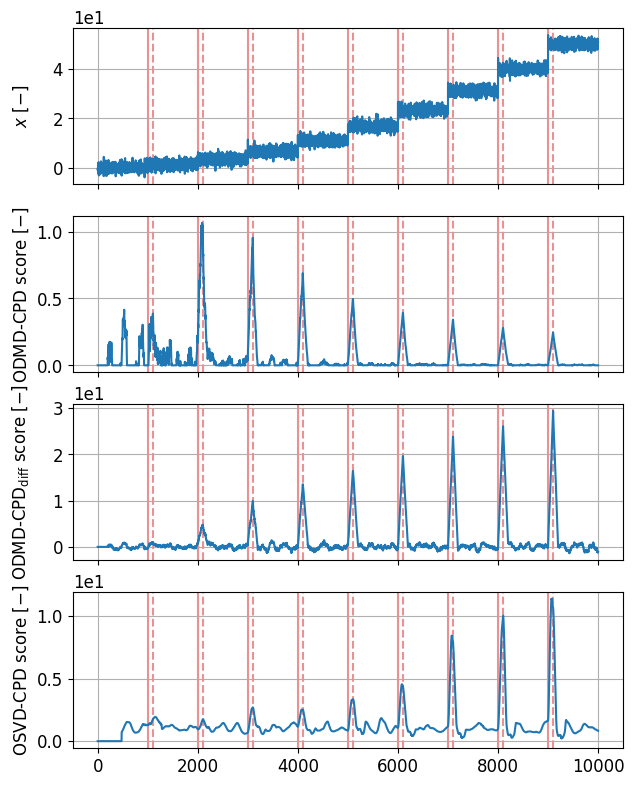

In [ ]:
# [donotremove]
# Load reference scores in long list format
scores_ref_ = np.genfromtxt("data/synthetic-steps/scores.txt").reshape(
    -1,
    10000,
)

# Initialize parameters
# Kawahara 2007 parameters
window_size = 100
hn = 3
ref_size = 100
test_size = 100
r = 2

# Iterate over all example datasets
n_datasets = 1
for n_d in range(n_datasets):
    # Read data
    X = np.genfromtxt(f"data/synthetic-steps/y{n_d}.txt", dtype=float)

    # Take batches from scores_ref list based on length of X
    scores_ref = scores_ref_[n_d, :]

    hankelizer = Hankelizer(hn)

    # Initialize Transformer
    # Using Rolling requires scaler to be added
    odmd = Rolling(
        OnlineDMD(
            r=r,
            initialize=window_size,
            w=1.0,
            exponential_weighting=False,
            seed=42,
        ),
        window_size + 1,
    )
    # Initialize Change-Point Detector
    subid_dmd = SubIDChangeDetector(
        odmd,
        ref_size=ref_size,
        test_size=test_size,
        grace_period=window_size + test_size + 1,
    )

    # Build pipeline
    pipeline_dmd = hankelizer | subid_dmd

    # Prepare arrays for storing results
    scores_dmd = np.zeros(X.shape[0], dtype=float)
    scores_dmd_diff = np.zeros(X.shape[0], dtype=complex)
    dist = np.zeros((X.shape[0], 2), dtype=complex)
    modes = np.empty((X.shape[0], hn, r), dtype=float)
    mean_modes = np.empty(X.shape[0], dtype=float)
    svs = np.zeros((X.shape[0], r, r), dtype=float)
    us_dmd = np.zeros((X.shape[0], hn, r), dtype=float)
    As = np.zeros((X.shape[0], r, r), dtype=float)

    # Run pipeline
    for i, (x) in tqdm(
        enumerate(X),
        total=len(X),
        mininterval=1.0,
        desc="Snapshots processed",
    ):
        scores_dmd[i] = pipeline_dmd.score_one({"x": x})
        dist[i, :] = subid_dmd.distances
        scores_dmd_diff[i] = dist[i, 1] - dist[i, 0]

        pipeline_dmd.learn_one({"x": x})

        if subid_dmd.n_seen > window_size + test_size:
            modes[i, :, :] = odmd.modes.real
            mean_modes[i] = modes[i, :, :].mean()
            svs[i, :, :] = odmd._svd._S
            us_dmd[i, :, :] = odmd._svd._U
            As[i, :, :] = odmd.A

    fig, axs = plot_chd(
        {
            "$x~[-]$": X,
            "ODMD-CPD score [$-$]": scores_dmd.real,
            "ODMD-CPD$_\\mathrm{diff}$ score [$-$]": scores_dmd_diff.real,
            "OSVD-CPD score [$-$]": scores_ref.real,
        },
        list(range(1000, X.shape[0], 1000)),
        grace_period=test_size,
    )

    fig_name = (
        f"results/.synthetic-steps/y{n_d}-chd_r{r}_{ref_size}_{test_size}-"
        f"{f'roll_{odmd.window_size}' if isinstance(odmd, Rolling) else 'noroll'}-"
        f"dmd_w{odmd.w}-h{hn}.pdf"
    )

    Path(fig_name).parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(fig_name)

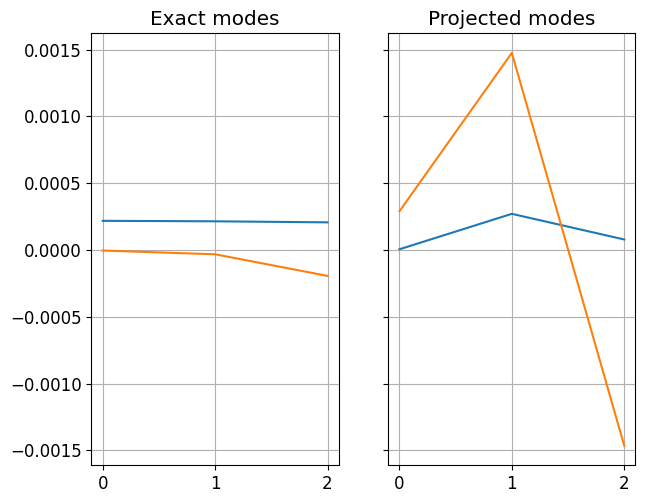

In [ ]:
# [donotremove]
_, axs = plt.subplots(1, 2, sharey=True)
axs[0].set_title("Exact modes")
axs[0].plot(
    odmd._Y.T @ odmd._svd._Vt.T @ np.diag(1 / odmd._svd._S) @ odmd.eig[1],
)
axs[1].set_title("Projected modes")
axs[1].plot(odmd._svd._U @ np.diag(1 / odmd._svd._S) @ odmd.eig[1])

In [ ]:
hX = hankel(X, hn)

svs_batch = np.zeros((hX.shape[0], 2), dtype=float)
us_batch = np.zeros((hX.shape[0], hX.shape[1], 2), dtype=float)
for i in range(0, hX.shape[0], 1000):
    if len(hX.shape) > 1 and r < hX.shape[1]:
        u, s, v = sp.sparse.linalg.svds(hX[0 : i + 1000].T, k=r)
        u, s, v = _sort_svd(u, s, v)
    else:
        u, s, v = np.linalg.svd(hX[0 : i + 1000], full_matrices=False)
    svs_batch[i : i + 1000, :] = s
    us_batch[i : i + 1000, :] = u

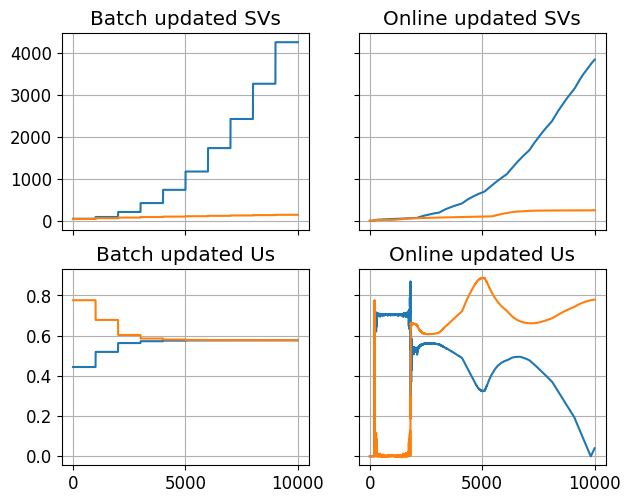

In [ ]:
# [donotremove]
_, axs = plt.subplots(2, 2, sharey="row", sharex="col")
axs = axs.flatten()
axs[0].set_title("Batch updated SVs")
axs[0].plot(svs_batch)
axs[1].set_title("Online updated SVs")
axs[1].plot(np.array(svs[:, 0, :]))
axs[2].set_title("Batch updated Us")
axs[2].plot(np.abs(us_batch[:, :2, 0]))
axs[3].set_title("Online updated Us")
axs[3].plot(np.abs(us_dmd[:, :2, 0]))